In [1]:
# Generating a Mock Galaxy image for the Press Release mock image ROSALIA
# 
# Alejandro Borlaff - NASA Ames Research Center
# a.s.borlaff@nasa.gov - August 5, 2026

# Plan: 
# Make a mock exposure object. 
# Run stray-light model. 

import rosalia as rs 
from astropy.time import Time
import os
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
os.chdir("/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK")
import numpy as np
from astropy.io import fits

In [2]:
r_alpha_name = "/Users/aborlaff/NASA/FIRE/r_alpha_FIRE.fits"
g_alpha_name = "/Users/aborlaff/NASA/FIRE/g_alpha_FIRE.fits"
b_alpha_name = "/Users/aborlaff/NASA/FIRE/b_alpha_FIRE.fits"

r_beta_name = "/Users/aborlaff/NASA/FIRE/r_beta_FIRE.fits"
g_beta_name = "/Users/aborlaff/NASA/FIRE/g_beta_FIRE.fits"
b_beta_name = "/Users/aborlaff/NASA/FIRE/b_beta_FIRE.fits"

r_alpha = fits.open(r_alpha_name)
g_alpha = fits.open(g_alpha_name)
b_alpha = fits.open(b_alpha_name)

r_beta = fits.open(r_beta_name)
g_beta = fits.open(g_beta_name)
b_beta = fits.open(b_beta_name)

import numpy as np
def paste_frame_at(frame, canvas, xlow, ylow):
    canvas[xlow:xlow+frame.shape[0], ylow:ylow+frame.shape[1]] = np.nansum([canvas[xlow:xlow+frame.shape[0], ylow:ylow+frame.shape[1]],frame], axis=0)/2
    return(canvas)
    

In [31]:
# Calculate transformation to calibrated units. Aprox 
# Obs - Max 2.60 Min 1.5 - Target = MAx 50, min = 0.001
max_obs = 0.60
min_obs = 0.20
max_want = 17
min_want = 30
m = (max_want - min_want)/(max_obs-min_obs)
c = min_want - m*min_obs
print(m)
print(c)

-32.5
36.5


In [32]:
print(m*1.5+c)

-12.25


'FIRE_b_galaxy_Roman_PRAug2026.fits'

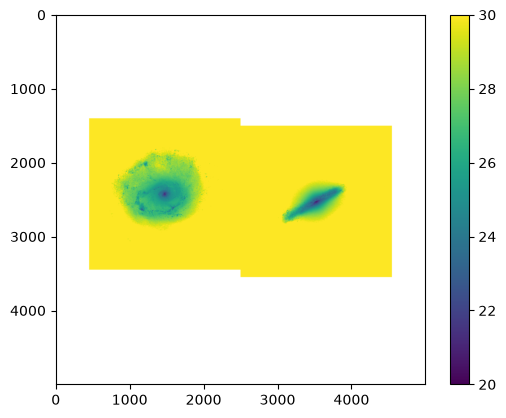

In [35]:
canvas_r = np.zeros((5000,5000))*np.nan
canvas_g = np.zeros((5000,5000))*np.nan
canvas_b = np.zeros((5000,5000))*np.nan

# Paste alpha

canvas_r = paste_frame_at(frame=r_alpha[0].data, canvas=canvas_r, xlow=1400, ylow=452)
canvas_r = paste_frame_at(frame=np.rot90(r_beta[0].data), canvas=canvas_r, xlow=1500, ylow=2500)

canvas_g = paste_frame_at(frame=g_alpha[0].data, canvas=canvas_g, xlow=1400, ylow=452)
canvas_g = paste_frame_at(frame=np.rot90(g_beta[0].data), canvas=canvas_g, xlow=1500, ylow=2500)

canvas_b = paste_frame_at(frame=b_alpha[0].data, canvas=canvas_b, xlow=1400, ylow=452)
canvas_b = paste_frame_at(frame=np.rot90(b_beta[0].data), canvas=canvas_b, xlow=1500, ylow=2500)


# 
ra = 88.23938768241827  # Right ascension, in degrees. 
dec = -48.53277317761877  # Declination, in degrees.
PA = 98.22514198825647  # Position angle, in degrees.


canvas_r = m*canvas_r+c
canvas_g = m*canvas_g+c
canvas_b = m*canvas_b+c

plt.imshow(canvas_r, vmin=20, vmax=30)
plt.colorbar()

canvas_r_es = rs.detectors.mu2fe(mu=canvas_r, instrument="WFI", filter_name="F184", telescope="Roman")
canvas_g_es = rs.detectors.mu2fe(mu=canvas_g, instrument="WFI", filter_name="F129", telescope="Roman")
canvas_b_es = rs.detectors.mu2fe(mu=canvas_b, instrument="WFI", filter_name="F087", telescope="Roman")


wcs = rs.utils.create_custom_wcs(crpix=[2450,3500], crval=[ra, dec], crota=[-PA, -PA], cdelt=[-0.4/60/60, 0.4/60/60])

rs.utils.save_fits(canvas_r_es.value, "FIRE_r_galaxy_Roman_PRAug2026.fits", wcs)
rs.utils.save_fits(canvas_g_es.value, "FIRE_g_galaxy_Roman_PRAug2026.fits", wcs)
rs.utils.save_fits(canvas_b_es.value, "FIRE_b_galaxy_Roman_PRAug2026.fits", wcs)



In [ ]:
rs.detectors.fe2mu(fe=0.001, instrument="WFI", filter_name="F129", telescope="Roman")

In [ ]:
1-0.15/0.49

In [36]:
import numpy as np
# Reprojecting to the scaled version 

r = fits.open("FIRE_r_galaxy_Roman_PRAug2026.fits") 
g = fits.open("FIRE_g_galaxy_Roman_PRAug2026.fits")
b = fits.open("FIRE_b_galaxy_Roman_PRAug2026.fits")



stray_scaled_drz_name = "/Users/aborlaff/NASA/ROSALIA/notebooks/MOCK/PR_mock_F158_Roman_RA_088.239_DEC_-48.533_MJD_61375.00000_PA_098.23_stray_drz_scaled.fits"
stray_scaled_drz = fits.open(stray_scaled_drz_name)
from reproject import reproject_interp

r_reprojected, footprint = reproject_interp(r[0], stray_scaled_drz[0].header, parallel=True)
g_reprojected, footprint = reproject_interp(g[0], stray_scaled_drz[0].header, parallel=True)
b_reprojected, footprint = reproject_interp(b[0], stray_scaled_drz[0].header, parallel=True)

r_reprojected[np.isnan(stray_scaled_drz[0].data)] = np.nan
g_reprojected[np.isnan(stray_scaled_drz[0].data)] = np.nan
b_reprojected[np.isnan(stray_scaled_drz[0].data)] = np.nan


r_reprojected[r_reprojected<0] = 0
g_reprojected[g_reprojected<0] = 0
b_reprojected[b_reprojected<0] = 0

rs.utils.save_fits(r_reprojected,  "FIRE_r_galaxy_Roman_PRAug2026_repro.fits", stray_scaled_drz[0].header)
rs.utils.save_fits(g_reprojected,  "FIRE_g_galaxy_Roman_PRAug2026_repro.fits", stray_scaled_drz[0].header)
rs.utils.save_fits(b_reprojected,  "FIRE_b_galaxy_Roman_PRAug2026_repro.fits", stray_scaled_drz[0].header)



'FIRE_b_galaxy_Roman_PRAug2026_repro.fits'

In [ ]:
plt.imshow(mu)
plt.colorbar()